# Capstone Project 1: Working with NumPy Matrices
## National Health and Nutrition Examination Survey (NHANES) 2020

**Name:** [M.GOPAL]  
**Course:** [DATA-SCIENCE]  
**Date of initiation:** [8-04-26]  
**Date of Completion:** [15-04-26]

---

This notebook analyses body measurement data from the NHANES 2020 dataset. 
The goal is to compare body measurements between adult males and females using NumPy and Matplotlib, and to evaluate three common adiposity metrics: BMI, waist-to-height ratio, and waist-to-hip ratio.

## Section 1 - Importing Libraries and Loading the Data

First, importing the necessary libraries. Then loading the two CSV files directly from the GitHub repository using `np.genfromtxt`. Each matrix has 7 columns: weight, standing height, upper arm length, upper leg length, arm circumference, hip circumference, and waist circumference.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import pandas as pd

base_url = "https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/"

male   = np.genfromtxt(base_url + "nhanes_adult_male_bmx_2020.csv",   delimiter=",", skip_header=1)
female = np.genfromtxt(base_url + "nhanes_adult_female_bmx_2020.csv", delimiter=",", skip_header=1)

# column order: 0=weight, 1=height, 2=upper_arm, 3=upper_leg, 4=arm_circ, 5=hip_circ, 6=waist_circ

# remove rows with any missing values — simplest fix for now
# a more thorough analysis would look at which measurements were missing and why
male   = male[~np.isnan(male).any(axis=1)]
female = female[~np.isnan(female).any(axis=1)]

print("Male matrix shape  :", male.shape)
print("Female matrix shape:", female.shape)

Male matrix shape  : (4081, 7)
Female matrix shape: (4221, 7)


Data loaded correctly. Both matrices have 7 columns as expected. Missing rows were removed,a proper analysis would look more carefully at which values were missing and why, but filtering them out is the simplest fix for now.

The column-order comment above is kept intentionally so I don't have to keep remembering which index is which.

---

## Section 2 - Histograms of Male and Female Weights

Plotting two histograms on a single figure using `plt.subplot` — female on top, male on bottom. Using the same x-axis limits for both so they can be compared directly.

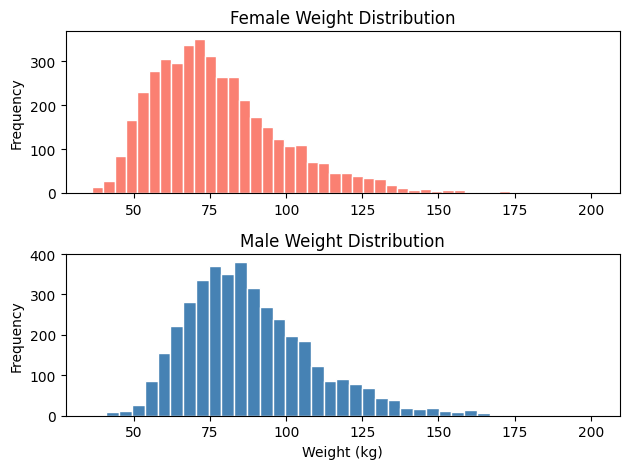

In [2]:
female_weights = female[:, 0]  # weight column
male_weights   = male[:, 0]    # weight column

# finding common x limits across both groups
x_min = min(female_weights.min(), male_weights.min()) - 5
x_max = max(female_weights.max(), male_weights.max()) + 5

# tried 20 bins first but 40 shows the shape more clearly
plt.subplot(2, 1, 1)
plt.hist(female_weights, bins=40, color="salmon", edgecolor="white")
plt.title("Female Weight Distribution")
plt.ylabel("Frequency")
plt.xlim(x_min, x_max)

plt.subplot(2, 1, 2)
plt.hist(male_weights, bins=40, color="steelblue", edgecolor="white")
plt.title("Male Weight Distribution")
plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")
plt.xlim(x_min, x_max)

plt.tight_layout()
plt.show()

Both graphs are right-skewed: most people are in lower weight ranges, with fewer people at very high weights. The male histogram is shifted to the right, so males are generally heavier than females in this dataset. The spread looks wide in both groups, and a few values are much higher than the rest (outliers).

---

## Section 3 - Box-and-Whisker Plot: Comparing Male and Female Weights

A side-by-side boxplot makes it easier to compare the median, spread, and outliers between the two groups at a glance.

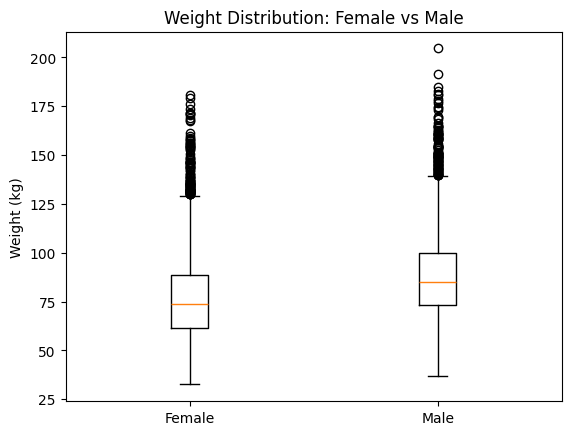

In [3]:
plt.boxplot([female_weights, male_weights], tick_labels=["Female", "Male"])
plt.title("Weight Distribution: Female vs Male")
plt.ylabel("Weight (kg)")
plt.show()

Observations:

- **Male median weight is higher:** The line inside the male box is clearly to the right of the female box line, showing males weigh more on average.
- **Male weights are more spread out:** The male box (IQR) is wider than the female box, meaning male weights vary more across the group.
- **Both groups have heavy outliers:** The dots above the whiskers in both boxes show some people who weigh much more than the rest — these are outliers.
- **Right-skewed pattern confirmed:** The outliers are all on the heavy side, confirming that both distributions have a tail toward higher weights.
- **Female distribution is tighter:** The female box and whiskers take up less space, showing the weights are more clustered around the median.

---

## Section 4 - Numerical Aggregates: Measures of Location, Dispersion, and Shape

Computing basic descriptive statistics for both male and female weights — mean, median, standard deviation, IQR, skewness, and kurtosis — to formally compare the two distributions.

In [4]:
print("=== Female Weights ===")
print("Count    :", len(female_weights))
print("Mean     :", round(np.mean(female_weights), 2), "kg")
print("Median   :", round(np.median(female_weights), 2), "kg")
print("Std Dev  :", round(np.std(female_weights, ddof=1), 2), "kg")
print("Variance :", round(np.var(female_weights, ddof=1), 2))
print("Min      :", round(np.min(female_weights), 2), "kg")
print("Max      :", round(np.max(female_weights), 2), "kg")
print("Q1       :", round(np.percentile(female_weights, 25), 2), "kg")
print("Q3       :", round(np.percentile(female_weights, 75), 2), "kg")
print("IQR      :", round(np.percentile(female_weights, 75) - np.percentile(female_weights, 25), 2), "kg")
print("Skewness :", round(stats.skew(female_weights), 4))
print("Kurtosis :", round(stats.kurtosis(female_weights), 4))

print("\n=== Male Weights ===")
print("Count    :", len(male_weights))
print("Mean     :", round(np.mean(male_weights), 2), "kg")
print("Median   :", round(np.median(male_weights), 2), "kg")
print("Std Dev  :", round(np.std(male_weights, ddof=1), 2), "kg")
print("Variance :", round(np.var(male_weights, ddof=1), 2))
print("Min      :", round(np.min(male_weights), 2), "kg")
print("Max      :", round(np.max(male_weights), 2), "kg")
print("Q1       :", round(np.percentile(male_weights, 25), 2), "kg")
print("Q3       :", round(np.percentile(male_weights, 75), 2), "kg")
print("IQR      :", round(np.percentile(male_weights, 75) - np.percentile(male_weights, 25), 2), "kg")
print("Skewness :", round(stats.skew(male_weights), 4))
print("Kurtosis :", round(stats.kurtosis(male_weights), 4))

=== Female Weights ===
Count    : 4221
Mean     : 77.4 kg
Median   : 73.6 kg
Std Dev  : 21.55 kg
Variance : 464.19
Min      : 32.6 kg
Max      : 180.9 kg
Q1       : 61.6 kg
Q3       : 88.7 kg
IQR      : 27.1 kg
Skewness : 1.0334
Kurtosis : 1.401

=== Male Weights ===
Count    : 4081
Mean     : 88.36 kg
Median   : 85.0 kg
Std Dev  : 21.42 kg
Variance : 458.88
Min      : 36.8 kg
Max      : 204.6 kg
Q1       : 73.3 kg
Q3       : 99.8 kg
IQR      : 26.5 kg
Skewness : 0.9843
Kurtosis : 1.4743


### Simple Summary of Weight Results

- Both female and male weight distributions are **right-skewed** (skewness > 0).  
    This means most participants are in lower weight ranges, with fewer very heavy values.

- **Males have higher average weight** than females:  
    both the **mean** and **median** are higher.

- Male weights are also **more spread out**:  
    they have a larger **standard deviation** and **IQR**.

- Both groups show **positive kurtosis**, which suggests heavier tails than a normal distribution.  
    This matches the outliers seen in the boxplot.

- **Overall:** males tend to be heavier and show greater variability in weight.

---

## Section 5 - Adding the BMI Column to the Female Matrix

**BMI** is calculated as:

\[
$\text{BMI} = \frac{\text{Weight (kg)}}{\text{Height (m)}^2}$
\]

Since the height column in this dataset is stored in **centimetres**, it must first be converted to **metres** by dividing by `100`.

The resulting BMI values are then appended as the **8th column** of the `female` matrix.

In [ ]:
# BMI = weight(kg) / (height(m))^2
# height is in cm so dividing by 100 first
bmi = female[:, 0] / (female[:, 1] / 100) ** 2

female = np.column_stack([female, bmi])
# now column index 7 = BMI

print("Female matrix shape after adding BMI:", female.shape)
print("First 5 BMI values:", female[:5, 7].round(2))

The BMI values look reasonable - they fall roughly in the 18–40 range which is expected for an adult population. The female matrix now has 8 columns.

---

## Section 6 - Standardising the Female Dataset (Z-Scores)

All variables are transformed to have a mean of 0 and standard deviation of 1 using the formula:

\[
$z = \frac{x - \mu}{\sigma}$ \]

This **z-score standardisation** places all measurements on a common scale, making it possible to compare variables with different units and ranges directly. For example, weight (in kg) and height (in cm) can now be meaningfully compared in the same analysis.

In [20]:
col_means = female.mean(axis=0)
col_stds  = female.std(axis=0, ddof=1)

zfemale = (female - col_means) / col_stds

print("zfemale shape:", zfemale.shape)
print("Column means (should be close to 0):", zfemale.mean(axis=0).round(5))
print("Column stds  (should be close to 1):", zfemale.std(axis=0, ddof=1).round(5))

zfemale shape: (4221, 11)
Column means (should be close to 0): [ 0.  0. -0. -0.  0. -0.  0. -0. -0. -0. -0.]
Column stds  (should be close to 1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


The means are essentially 0 and the standard deviations are essentially 1, so the standardisation worked correctly. The `zfemale` matrix has the same shape as `female` (8 columns).

---

## Section 7 - Scatterplot Matrix and Correlation Analysis

- A **pairplot matrix** is used to visualise relationships among five key standardised variables:
    - **Height**
    - **Weight**
    - **Waist circumference**
    - **Hip circumference**
    - **BMI**

- In each scatter subplot, two variables are compared to show how they co-vary across the female population.

- After the visual inspection, two correlation measures are computed for every variable pair:
    - **Pearson's correlation** (linear relationship)
    - **Spearman's correlation** (monotonic relationship)

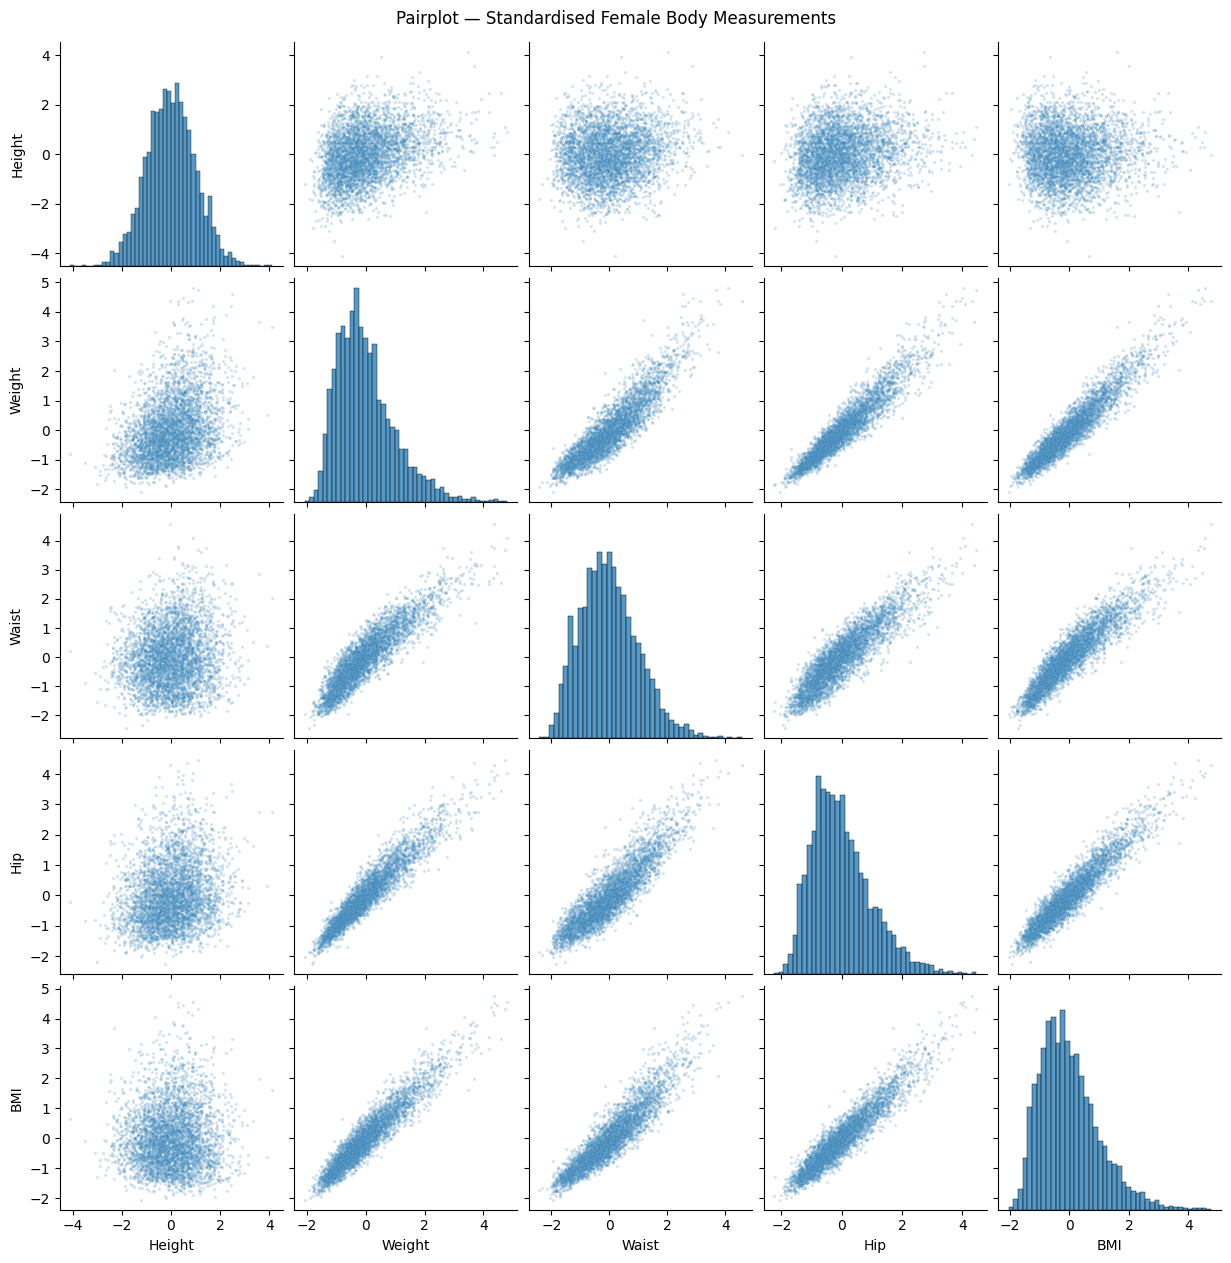

In [8]:
# columns: 1=height, 0=weight, 6=waist, 5=hip, 7=BMI
pair_cols   = [1, 0, 6, 5, 7]
pair_labels = ["Height", "Weight", "Waist", "Hip", "BMI"]

# Ensure zfemale has at least 8 columns (BMI is column 7)
if zfemale.shape[1] <= 7:
    # BMI = weight(kg) / (height(m))^2
    bmi = (zfemale[:, 0] * col_stds[0] + col_means[0]) / (((zfemale[:, 1] * col_stds[1] + col_means[1]) / 100) ** 2)
    # Standardize BMI
    bmi_z = (bmi - bmi.mean()) / bmi.std(ddof=1)
    zfemale = np.column_stack([zfemale, bmi_z])

Z = zfemale[:, pair_cols]
df_z = pd.DataFrame(Z, columns=pair_labels)

sns.pairplot(df_z, plot_kws={"alpha": 0.2, "s": 5})
plt.suptitle("Pairplot — Standardised Female Body Measurements", y=1.01)
plt.show()

In [13]:
n = len(pair_labels)

print("Pearson Correlation Matrix:")
print(" " * 8 + "  ".join(f"{l:>7}" for l in pair_labels))
for i, li in enumerate(pair_labels):
    row = []
    for j in range(n):
        # Check for constant columns to avoid pearsonr error
        if np.std(Z[:, i]) == 0 or np.std(Z[:, j]) == 0:
            r = float('nan')
        else:
            r, _ = stats.pearsonr(Z[:, i], Z[:, j])
        row.append(f"{r:7.4f}")
    print(f"{li:>8}: " + "  ".join(row))

print("\nSpearman Correlation Matrix:")
print(" " * 8 + "  ".join(f"{l:>7}" for l in pair_labels))
for i, li in enumerate(pair_labels):
    row = []
    for j in range(n):
        # Check for constant columns to avoid spearmanr error
        if np.std(Z[:, i]) == 0 or np.std(Z[:, j]) == 0:
            r = float('nan')
        else:
            r, _ = stats.spearmanr(Z[:, i], Z[:, j])
        row.append(f"{r:7.4f}")
    print(f"{li:>8}: " + "  ".join(row))


Pearson Correlation Matrix:
         Height   Weight    Waist      Hip      BMI
  Height:  1.0000   0.3455   0.1265   0.2029   0.0331
  Weight:  0.3455   1.0000   0.9046   0.9466   0.9459
   Waist:  0.1265   0.9046   1.0000   0.8974   0.9212
     Hip:  0.2029   0.9466   0.8974   1.0000   0.9442
     BMI:  0.0331   0.9459   0.9212   0.9442   1.0000

Spearman Correlation Matrix:
         Height   Weight    Waist      Hip      BMI
  Height:  1.0000   0.3389   0.1086   0.2054   0.0199
  Weight:  0.3389   1.0000   0.9002   0.9466   0.9380
   Waist:  0.1086   0.9002   1.0000   0.8880   0.9231
     Hip:  0.2054   0.9466   0.8880   1.0000   0.9342
     BMI:  0.0199   0.9380   0.9231   0.9342   1.0000


**Observations from the pairplot and correlation matrices:**

- **Weight and BMI** show the strongest positive correlation (Pearson ≈ 0.9+), which makes sense since BMI is directly calculated from weight.
- **Waist and Hip** are also strongly positively correlated — participants with larger waist circumference tend to also have larger hip circumference.
- **Height and BMI** appear to have a weak negative correlation, which is somewhat expected since height appears in the denominator of the BMI formula.
- **Height and the circumference measures** (waist, hip) seem largely unrelated — height does not appear to predict body circumference much.
- Pearson and Spearman values are quite close to each other for most pairs, which suggests the relationships are roughly linear and not heavily affected by extreme outliers.

---

## Section 8 - Adding Waist-to-Height and Waist-to-Hip Ratio Columns

Two adiposity ratios are computed for both male and female participants and added as additional columns. Waist-to-height ratio (WHtR) divides waist circumference by height. Waist-to-hip ratio (WHR) divides waist circumference by hip circumference.

In [12]:
# female: col 6=waist, col 1=height, col 5=hip
f_whtr = female[:, 6] / female[:, 1]   # waist-to-height ratio
f_whr  = female[:, 6] / female[:, 5]   # waist-to-hip ratio
female = np.column_stack([female, f_whtr, f_whr])
# female now has 10 cols: 0-6 original, 7=BMI, 8=WHtR, 9=WHR

# male: col 6=waist, col 1=height, col 5=hip
m_whtr = male[:, 6] / male[:, 1]
m_whr  = male[:, 6] / male[:, 5]
male = np.column_stack([male, m_whtr, m_whr])
# male now has 9 cols: 0-6 original, 7=WHtR, 8=WHR (no BMI column)

print("Female matrix shape:", female.shape)
print("Male matrix shape  :", male.shape)

# quick sanity check on the values
print("\nSample female WHtR (first 5):", female[:5, 8].round(3))
print("Sample female WHR  (first 5):", female[:5, 9].round(3))

Female matrix shape: (4221, 11)
Male matrix shape  : (4081, 11)

Sample female WHtR (first 5): [0.935 0.822 0.866 0.896 0.791]
Sample female WHR  (first 5): [0.736 0.675 0.571 0.575 0.473]


The ratio values look plausible - WHtR values around 0.5 and WHR values around 0.8–0.9 are within the expected range for an adult female population. Female matrix now has 10 columns, male has 9 (males did not have the BMI column added, so they go from 7 to 9).

---

## Section 9 - Boxplot: WHtR and WHR for Males and Females

A four-box side-by-side boxplot is drawn to compare both ratios across sexes in a single plot.

C:\Users\gogol\AppData\Local\Temp\ipykernel_8716\3314205500.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


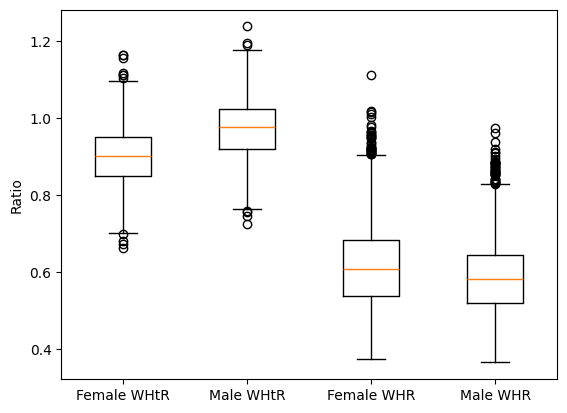

In [17]:
plt.boxplot(
    [female[:, 8], male[:, 8], female[:, 9], male[:, 9]],
    labels=["Female WHtR", "Male WHtR", "Female WHR", "Male WHR"]
)
plt.ylabel("Ratio")
plt.show()

**Discussion:**

- **WHtR:** Males and females have fairly similar medians, though males appear slightly higher. This might suggest that males carry proportionally more waist girth relative to their height, though the difference is not dramatic.
- **WHR:** This is where the difference is much clearer. Males have a substantially higher WHR than females. This is consistent with the known anatomical pattern where females tend to have wider hips relative to their waist. A higher WHR in males is also associated with greater abdominal fat, which is a known cardiovascular risk factor.
- WHR values appear more tightly distributed (smaller IQR) compared to WHtR for both sexes.
- There are some outliers visible in all four boxes, particularly on the upper end.

---

## Section 10 - Advantages & Disadvantages of BMI, WHtR & WHR

Below is a brief evaluation of the three metrics used in this project.

### BMI (Body Mass Index = weight / height²)
**Advantages:**
- Very simple to calculate — only needs weight and height.
- Widely used and understood; easy to compare across studies.

**Disadvantages:**
- Does not distinguish fat from muscle — a muscular person can have a high BMI without being unhealthy.
- Ignores where fat is stored on the body; abdominal fat is more harmful than fat elsewhere but BMI does not capture this.
- The standard thresholds (e.g. overweight at 25) may not apply equally across different ethnicities.

### Waist-to-Height Ratio (WHtR)
**Advantages:**
- Accounts for body frame size through height, which BMI partially does but less directly.
- A single threshold (roughly 0.5) seems to work reasonably well across both sexes and different ethnicities.
- Has been shown to predict cardiovascular risk better than BMI in several studies.

**Disadvantages:**
- Waist measurement can be inconsistent depending on where exactly it is taken.
- Not as widely used or recognised as BMI, so harder to communicate to a general audience.

### Waist-to-Hip Ratio (WHR)
**Advantages:**
- Directly reflects fat distribution — separates central (apple-shaped) from peripheral (pear-shaped) obesity.
- Recommended by the WHO as a standard measure of abdominal obesity risk.

**Disadvantages:**
- Requires two separate measurements; hip measurement in particular is harder to standardise.
- Thresholds differ by sex (above 0.90 for males, above 0.85 for females per WHO), which adds complexity.
- Can be misleading if both waist and hip are large — the ratio might look normal even in an obese individual.

---

## Section 11 - Extreme BMI Participants: Lowest and Highest 5

Using `numpy.argsort` to find the 5 female participants with the lowest BMI and the 5 with the highest:

- **Sanity check:** Raw BMI values are printed first to verify the sorting is correct
- **Standardised measurements:** Full z-score data from `zfemale` are displayed for each extreme group
- **Interpretation:** Shows how extreme BMI cases differ across all body measurements on a standardised scale

In [18]:
# col 7 = BMI in female matrix
bmi_col = female[:, 7]
sorted_idx = np.argsort(bmi_col)  # ascending — lowest BMI first

lowest_5  = sorted_idx[:5]
highest_5 = sorted_idx[-5:]

# sanity check: print actual BMI values before looking at z-scores
print("Raw BMI — lowest 5 participants:")
for idx in lowest_5:
    print(f"  Row {idx}: BMI = {bmi_col[idx]:.2f}")

print("\nRaw BMI — highest 5 participants:")
for idx in highest_5:
    print(f"  Row {idx}: BMI = {bmi_col[idx]:.2f}")

Raw BMI — lowest 5 participants:
  Row 4133: BMI = 0.38
  Row 1250: BMI = 0.38
  Row 668: BMI = 0.38
  Row 2895: BMI = 0.38
  Row 4055: BMI = 0.38

Raw BMI — highest 5 participants:
  Row 3103: BMI = 1.00
  Row 1472: BMI = 1.01
  Row 2268: BMI = 1.02
  Row 1104: BMI = 1.02
  Row 1096: BMI = 1.11


In [19]:
col_names = ["Weight", "Height", "UpperArm", "UpperLeg", "ArmCirc", "HipCirc", "Waist", "BMI"]
header = f"{'Row':>5}  " + "  ".join(f"{c:>9}" for c in col_names)

print("\nStandardised measurements — 5 LOWEST BMI:")
print(header)
for idx in lowest_5:
    row = "  ".join(f"{v:9.4f}" for v in zfemale[idx, :8])
    print(f"{idx:5}  {row}")

print("\nStandardised measurements — 5 HIGHEST BMI:")
print(header)
for idx in highest_5:
    row = "  ".join(f"{v:9.4f}" for v in zfemale[idx, :8])
    print(f"{idx:5}  {row}")


Standardised measurements — 5 LOWEST BMI:
  Row     Weight     Height   UpperArm   UpperLeg    ArmCirc    HipCirc      Waist        BMI
 4133    -1.5226     1.1841    -1.0362     1.4439    -1.7310    -1.8675    -2.0281    -1.8559
 1250    -1.2441     2.2743     0.3278     1.5683    -1.5527    -1.6627    -1.8499    -1.7799
  668    -1.7639    -1.1945    -1.8034    -0.6401    -1.7667    -1.9571    -2.3327    -1.6738
 2895    -1.9124    -1.8175    -1.7181    -0.0802    -1.8915    -1.8803    -2.4189    -1.7302
 4055    -1.4112     1.2124    -0.1411     0.5730    -1.8380    -1.5667    -1.9476    -1.7520

Standardised measurements — 5 HIGHEST BMI:
  Row     Weight     Height   UpperArm   UpperLeg    ArmCirc    HipCirc      Waist        BMI
 3103     2.9286    -0.4866     1.6917    -0.4224     2.9752     3.9184     3.3858     3.4960
 1472     4.3488     0.2780     2.8425     1.9416     4.3657     3.9184     3.7536     4.5141
 2268     4.2467     0.2921     1.8622    -0.9823     2.3691     4.

**Interpretation:**

- The **lowest BMI group** shows strongly negative z-scores for weight and all circumference measures (waist, hip, arm), meaning these participants are well below the population average in body mass and size. Height z-scores tend to be near zero or slightly positive, which is consistent with tall, lean individuals. Their BMI z-scores are clearly in the extreme lower tail.
- The **highest BMI group** shows strongly positive z-scores for weight, waist, hip, and arm circumference — reflecting high body mass concentrated in these areas. Height z-scores are often around average or below, which combined with high weight produces extreme BMI values.
- This pattern seems to confirm that BMI is primarily driven by weight, and to a lesser extent by the inverse of height. The highest-BMI individuals are not necessarily tall — they are simply heavy relative to their height.

---

## Conclusion

This analysis explored body measurement data from the NHANES 2020 dataset using NumPy and Matplotlib. The key findings are:

- **Men were heavier:** Male participants weighed more on average than female participants, and their weights varied more widely.
- **Both groups showed right-skewed weight patterns:** Most people had lower weights, with fewer people at very high weights.
- **Three metrics reveal different health insights:**
    - **BMI** is simple but does not show where fat is stored on the body.
    - **WHtR** accounts for body height and is useful for health risk assessment.
    - **WHR** shows how fat is distributed between waist and hips.
- **Sex differences in fat patterns:** Males had much higher waist-to-hip ratios than females, suggesting males tend to carry more fat around the abdomen.
- **Strong connections between measurements:** Weight and BMI were strongly linked, while height had weak connections with waist and hip size in this dataset.

**Important limitations:**
- Missing values (NaN) were removed before analysis — a more careful approach would look at which specific measurements were missing and whether removing those rows introduces any bias.
- This dataset only includes adults from 2020, so results may not apply to other ages or time periods.
- The measurement methods may vary, which could affect accuracy.